In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib as mpl

# Make text editable in vector PDF outputs (use TrueType fonts)
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42


def normalize_name(name: str) -> str:
    """Normalize disease names for keyword matching."""
    return str(name).replace("_", " ").strip()


# -----------------------------------------------------------------------------
# ClinVar / 1000 Genomes (ClinVar-annotated) settings
# -----------------------------------------------------------------------------
# Disease keyword sets used to map variants into tissue groups.
DISEASE_MAP = {'heart': ['Conotruncal Heart Malformations',
           'Cardiac Arrhythmia',
           'Hypertension',
           'Congenital Heart Disease',
           'Progressive Familial Heart Block',
           'Cardiomyopathy'],
 'brain': ['Amyotrophic Lateral Sclerosis',
           'Neurodegenerative Disease',
           'Parkinson Disease',
           'Neurodegeneration',
           'Autism',
           'Alzheimer Disease',
           'Schizophrenia',
           'Depression',
           'Anxiety'],
 'muscle': ['Muscular Dystrophy', 'Atrophy']}

# Panels to render for the ClinVar-like datasets
CLINVAR_TISSUES = ['heart', 'brain', 'muscle']

# Colors used in the original figure scripts
CLINVAR_TISSUE_COLORS = {'heart': '#FDD0A2', 'brain': '#C7E9C0', 'muscle': '#DADAEB'}


# -----------------------------------------------------------------------------
# TCGA settings
# -----------------------------------------------------------------------------
# Map cancer codes to the three tissue groups used in Fig S28a.
CANCER_TO_TISSUE = {'GBM': 'Brain',
 'LGG': 'Brain',
 'KIRC': 'Kidney',
 'KIRP': 'Kidney',
 'KICH': 'Kidney',
 'LUAD': 'Lung',
 'LUSC': 'Lung'}

# Full names shown on the y-axis.
CANCER_FULLNAME = {'GBM': 'Glioblastoma multiforme',
 'LGG': 'Brain Lower Grade Glioma',
 'KIRC': 'Kidney Renal Clear\nCell Carcinoma',
 'KIRP': 'Kidney Renal Papillary\nCell Carcinoma',
 'KICH': 'Kidney Chromophobe',
 'LUAD': 'Lung Adenocarcinoma',
 'LUSC': 'Lung Squamous\nCell Carcinoma'}

TCGA_TISSUE_ORDER = ['Kidney', 'Brain', 'Lung']
TCGA_TISSUE_COLORS = {'Kidney': '#DADAEB', 'Brain': '#C7E9C0', 'Lung': '#FDD0A2'}
TOP_N_TCGA = 10


# -----------------------------------------------------------------------------
# Aggregation helpers
# -----------------------------------------------------------------------------
def load_and_aggregate_clinvar_like(csv_path: str) -> dict[str, pd.DataFrame]:
    """Aggregate ClinVar-like CSVs that contain `RBP_list` and `ClinVar_CLNDN`.

    Returns:
        A dict mapping each tissue name to a DataFrame with columns:
        - Disease: matched disease keyword
        - Count: number of RBP-dependent variants matching that keyword
    """
    df = pd.read_csv(csv_path)

    required_cols = {"RBP_list", "ClinVar_CLNDN"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in {csv_path}: {sorted(missing)}")

    # Keep only RBP-dependent variants
    df = df[df["RBP_list"].notna() & (df["RBP_list"].astype(str).str.strip() != "")].copy()

    # tissue -> disease_keyword -> count
    tissue_disease_counts: dict[str, defaultdict[str, int]] = {
        t: defaultdict(int) for t in CLINVAR_TISSUES
    }

    for _, row in df.iterrows():
        if pd.isna(row["ClinVar_CLNDN"]):
            continue

        diseases = [normalize_name(d) for d in str(row["ClinVar_CLNDN"]).split("|")]

        for tissue in CLINVAR_TISSUES:
            keywords = DISEASE_MAP.get(tissue, [])
            matched = set()

            for d in diseases:
                d_low = d.lower()
                for kw in keywords:
                    if kw.lower() in d_low:
                        matched.add(kw)

            # Count each variant at most once per (tissue, keyword)
            for kw in matched:
                tissue_disease_counts[tissue][kw] += 1

    # Convert to DataFrames (ascending order works well for barh)
    dfs: dict[str, pd.DataFrame] = {}
    for tissue, counter in tissue_disease_counts.items():
        dfs[tissue] = (
            pd.DataFrame(counter.items(), columns=["Disease", "Count"])
            .sort_values("Count", ascending=True)
        )

    return dfs


def load_and_aggregate_tcga(csv_path: str, top_n: int = TOP_N_TCGA) -> dict[str, pd.DataFrame]:
    """Aggregate TCGA CSV (exported without a header): `tcga_diff.all.csv`.

    Expected columns (13):
        CHROM, POS, POS2, REF, ALT, ClinSig, strand, cancer, strand2, prefix,
        wild_type_coverage, mut_type_coverage, gene

    Returns:
        A dict mapping each tissue name to a DataFrame with columns:
        - Disease: cancer full name (for y-axis)
        - Count: number of unique (variant, RBP_base) pairs within that cancer and tissue
    """
    df = pd.read_csv(csv_path, header=None)
    df.columns = [
        "CHROM", "POS", "POS2", "REF", "ALT",
        "ClinSig", "strand", "cancer",
        "strand2", "prefix",
        "wild_type_coverage", "mut_type_coverage", "gene",
    ]

    # Keep rows that have a non-empty prefix (which encodes the RBP in this file)
    df = df[df["prefix"].notna() & (df["prefix"].astype(str).str.strip() != "")].copy()

    # Extract the RBP name and build a unique variant identifier
    df["RBP_base"] = df["prefix"].astype(str).str.split("_").str[0]
    df["variant"] = (
        df["CHROM"].astype(str) + ":" +
        df["POS"].astype(str) + ":" +
        df["REF"].astype(str) + ">" +
        df["ALT"].astype(str)
    )

    # Tissue group
    df["tissue"] = df["cancer"].map(CANCER_TO_TISSUE)

    # Unique (tissue, cancer, variant, RBP) pairs
    uniq_df = df[["tissue", "cancer", "variant", "RBP_base"]].drop_duplicates()

    # Count per tissue/cancer
    count_df = (
        uniq_df.groupby(["tissue", "cancer"])
        .size()
        .reset_index(name="Count")
    )

    # Build per-tissue plotting tables
    dfs: dict[str, pd.DataFrame] = {}
    for tissue in TCGA_TISSUE_ORDER:
        sub = count_df[count_df["tissue"] == tissue].copy()
        if sub.empty:
            dfs[tissue] = pd.DataFrame(columns=["Disease", "Count"])
            continue

        sub = sub.sort_values("Count", ascending=False).head(top_n)
        sub["Disease"] = sub["cancer"].map(CANCER_FULLNAME).fillna(sub["cancer"])
        dfs[tissue] = sub[["Disease", "Count"]].sort_values("Count", ascending=True)

    return dfs


def plot_panel_barh(
    dfs: dict[str, pd.DataFrame],
    tissues: list[str],
    tissue_colors: dict[str, str],
    xlabel: str = "Count of RBP-dependent variants",
    ylabel: str = "Disease",
    title_fn=None,
) -> None:
    """Plot a 1×N panel of horizontal bar charts (one per tissue)."""
    if title_fn is None:
        title_fn = lambda t: t.capitalize() if t.islower() else t

    fig, axes = plt.subplots(1, len(tissues), figsize=(18, 4))
    if len(tissues) == 1:
        axes = [axes]

    for ax, tissue in zip(axes, tissues):
        df_plot = dfs.get(tissue, pd.DataFrame(columns=["Disease", "Count"])).copy()
        if df_plot.empty:
            ax.set_axis_off()
            continue

        y = range(len(df_plot))
        labels = df_plot["Disease"].tolist()

        ax.barh(y, df_plot["Count"], color=tissue_colors.get(tissue))
        ax.set_yticks(list(y))
        ax.set_yticklabels(labels)
        ax.set_title(title_fn(tissue))
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.margins(y=0.2)  # reduce extra vertical whitespace
        ax.tick_params(axis="y", length=0)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


ClinVar (../ClinVar_TCGA_1000G_resources/clinvar_diff.variant_with_rbp.csv)

--- ClinVar | HEART ---
                 Disease  Count
          Cardiomyopathy    133
            Hypertension     16
      Cardiac Arrhythmia     11
Congenital Heart Disease      4

--- ClinVar | BRAIN ---
                      Disease  Count
Amyotrophic Lateral Sclerosis     69
                       Autism     46
            Neurodegeneration     21
            Parkinson Disease     12
            Alzheimer Disease     10
                Schizophrenia      6

--- ClinVar | MUSCLE ---
           Disease  Count
Muscular Dystrophy    118
           Atrophy     87


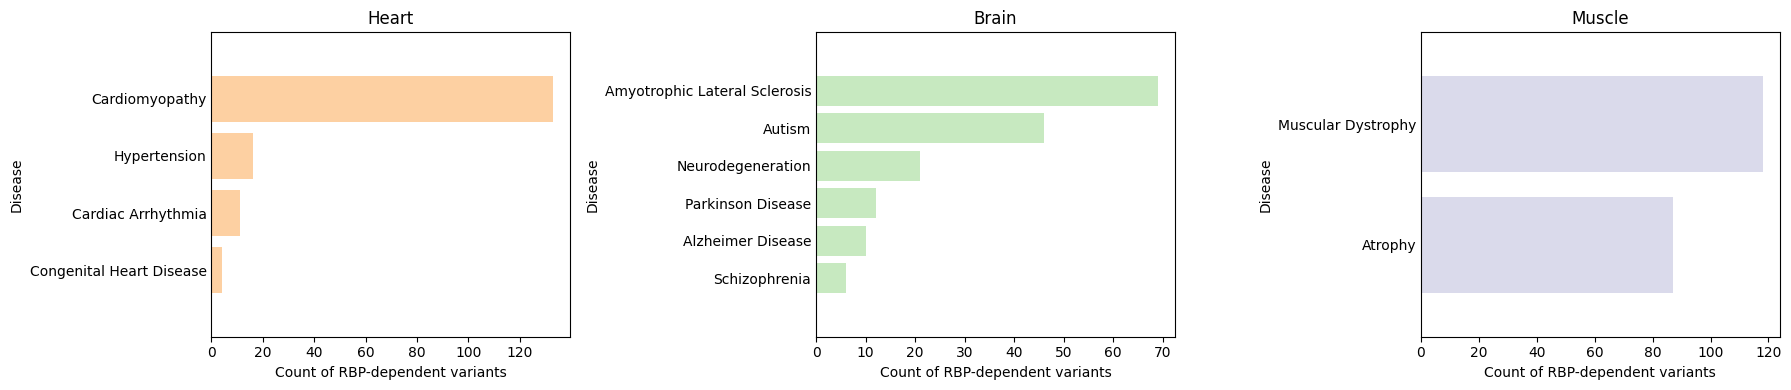


1000 Genomes (../ClinVar_TCGA_1000G_resources/1000genomes_diff.variant_with_rbp.csv)

--- 1000 Genomes | HEART ---
                 Disease  Count
          Cardiomyopathy    142
      Cardiac Arrhythmia     18
            Hypertension      8
Congenital Heart Disease      1

--- 1000 Genomes | BRAIN ---
                      Disease  Count
Amyotrophic Lateral Sclerosis     49
                       Autism     24
            Neurodegeneration     14
            Parkinson Disease      7
                Schizophrenia      5

--- 1000 Genomes | MUSCLE ---
           Disease  Count
Muscular Dystrophy    112
           Atrophy     59


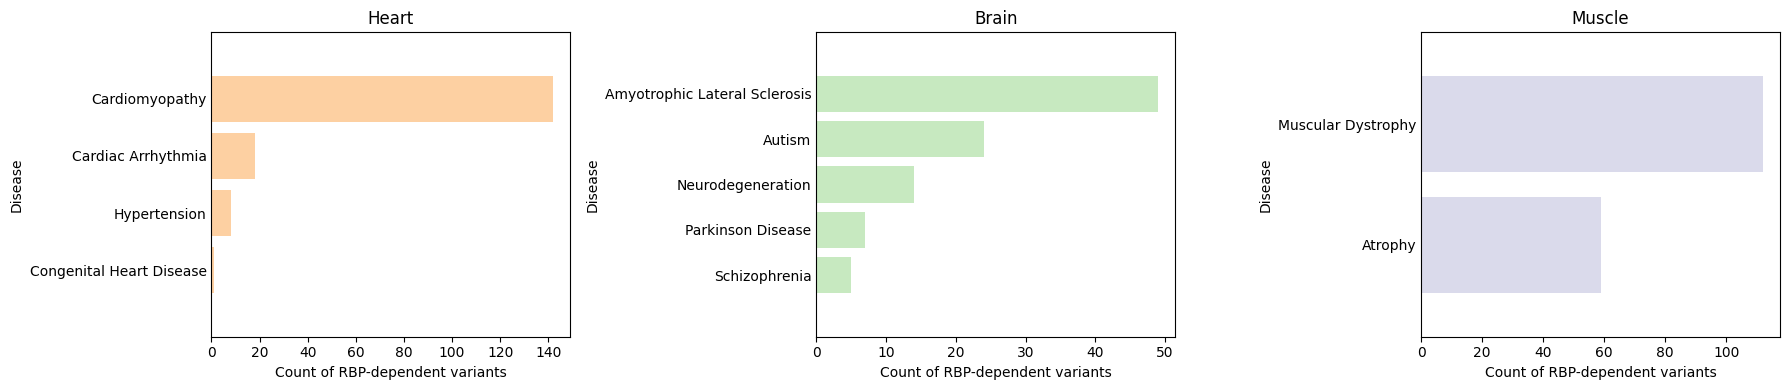


TCGA (../ClinVar_TCGA_1000G_resources/tcga_diff.all.csv)


/tmp/ipykernel_1378474/4159706324.py:139: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, header=None)



--- TCGA | Kidney (top 10) ---
                               Disease  Count
    Kidney Renal Clear\nCell Carcinoma   3734
Kidney Renal Papillary\nCell Carcinoma   3539
                    Kidney Chromophobe    417

--- TCGA | Brain (top 10) ---
                 Disease  Count
 Glioblastoma multiforme   7437
Brain Lower Grade Glioma   5430

--- TCGA | Lung (top 10) ---
                      Disease  Count
          Lung Adenocarcinoma  22392
Lung Squamous\nCell Carcinoma  20177


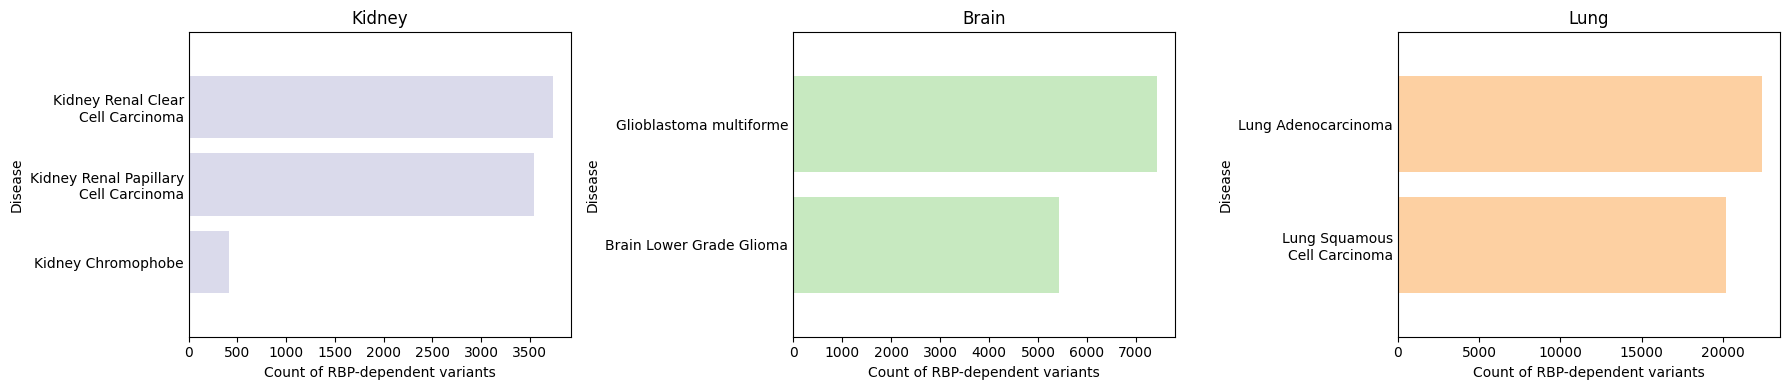

In [2]:
# Dataset configuration (loop instead of three near-identical blocks)
DATASETS = [
    {
        "label": "ClinVar",
        "kind": "clinvar_like",
        "csv_path": "../ClinVar_TCGA_1000G_resources/clinvar_diff.variant_with_rbp.csv",
    },
    {
        "label": "1000 Genomes",
        "kind": "clinvar_like",
        "csv_path": "../ClinVar_TCGA_1000G_resources/1000genomes_diff.variant_with_rbp.csv",
    },
    {
        "label": "TCGA",
        "kind": "tcga",
        "csv_path": "../ClinVar_TCGA_1000G_resources/tcga_diff.all.csv",
    },
]

for ds in DATASETS:
    print("\n" + "=" * 80)
    print(f"{ds['label']} ({ds['csv_path']})")
    print("=" * 80)

    if ds["kind"] == "clinvar_like":
        dfs = load_and_aggregate_clinvar_like(ds["csv_path"])

        # Print the top matches per tissue for quick inspection
        for tissue in CLINVAR_TISSUES:
            print(f"\n--- {ds['label']} | {tissue.upper()} ---")
            if dfs[tissue].empty:
                print("(no matches)")
            else:
                print(dfs[tissue].sort_values("Count", ascending=False).head(15).to_string(index=False))

        plot_panel_barh(
            dfs=dfs,
            tissues=CLINVAR_TISSUES,
            tissue_colors=CLINVAR_TISSUE_COLORS,
        )

    elif ds["kind"] == "tcga":
        dfs = load_and_aggregate_tcga(ds["csv_path"], top_n=TOP_N_TCGA)

        for tissue in TCGA_TISSUE_ORDER:
            print(f"\n--- {ds['label']} | {tissue} (top {TOP_N_TCGA}) ---")
            if dfs[tissue].empty:
                print("(no matches)")
            else:
                print(dfs[tissue].sort_values("Count", ascending=False).to_string(index=False))

        plot_panel_barh(
            dfs=dfs,
            tissues=TCGA_TISSUE_ORDER,
            tissue_colors=TCGA_TISSUE_COLORS,
            title_fn=lambda t: t,
        )
    else:
        raise ValueError(f"Unknown dataset kind: {ds['kind']}")